In [9]:
import pickle 
import pandas as pd 
import os


with open("pickles_Pm2/summary_data.pkl", "rb") as f: 
    data = pickle.load(f)


In [10]:
summary_data_df = pd.DataFrame(data)


In [11]:
os.chdir("/media/sf_VirtualShared/ratcliff-group-resources/workflows/TADF_HTVS/FF_geopt_xyz_files_Pm2")
xtb = pd.read_csv("pm2_homo_lumo.csv")


In [12]:
os.chdir('..')

In [14]:
import pickle
import pandas as pd
import re


with open("pickles_Pm2/summary_data.pkl", "rb") as f:
    data = pickle.load(f)

summary_data_df = pd.DataFrame(data)

summary_data_df = summary_data_df.loc[:, ~summary_data_df.columns.duplicated()].copy()


if "Name" not in summary_data_df.columns:
    summary_data_df = summary_data_df.reset_index().rename(columns={"index": "Name"})


junk = [c for c in summary_data_df.columns
        if re.match(r"^(HOMO_xtb_eV|LUMO_xtb_eV)(_.+)?$", str(c))]
if junk:
    summary_data_df = summary_data_df.drop(columns=junk)


summary_data_df["_merge_id"] = pd.to_numeric(
    summary_data_df["Name"].str.extract(r"_(\d+)$")[0], errors="coerce"
).astype("Int64")

xtb_clean = xtb.reset_index(drop=True).copy()
xtb_clean.columns = xtb_clean.columns.astype(str).str.strip()
xtb_clean["_merge_id"] = pd.to_numeric(xtb_clean["id"], errors="coerce").astype("Int64")
xtb_clean["HOMO_xtb_eV"] = pd.to_numeric(xtb_clean["HOMO_eV"], errors="coerce")
xtb_clean["LUMO_xtb_eV"] = pd.to_numeric(xtb_clean["LUMO_eV"], errors="coerce")
xtb_merge = xtb_clean[["_merge_id", "HOMO_xtb_eV", "LUMO_xtb_eV"]]

summary_data_df = summary_data_df.merge(xtb_merge, on="_merge_id", how="left")
summary_data_df = summary_data_df.drop(columns=["_merge_id"])


csv_gap = summary_data_df["LUMO_xtb_eV"] - summary_data_df["HOMO_xtb_eV"]
summary_data_df["xTB HOMO-LUMO gap / eV"] = summary_data_df["xTB HOMO-LUMO gap / eV"].fillna(csv_gap)


summary_data_df.head(10)

,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,Connected?,...,XTB Converged?,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV
0,Pm2,CC5(C)c1ccccc1N(c3ccc(c2cnc(C#N)nc2)cc3)c4ccccc45,False,False,False,50,1.0,2.432772,True,True,...,True,1.066162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pm2_1,CC1(C)c2ccccc2N(C2=CC=C(c3cnc(C#N)nc3)[B+]C2)c...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Pm2_2,CC1=CC(C)(C)C=CC=CC=C=[C+]N(c2ccc(-c3cnc(C#N)n...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pm2_3,CC1(C)C2=CC=C=[O+]C2N(c2ccc(-c3cnc(C#N)nc3)cc2...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Pm2_4,CC1=CC=C(N2c3ccccc3C(C)(C)c3ccccc32)C1c1cnc(C#...,False,False,False,52,0.647619,3.550541,True,True,...,True,1.398055,True,2.307315,1.793879,0.2438,-4.785816,-2.991937,-9.6062,-8.2081
5,Pm2_5,CC=C=C1CN(c2ccc(-c3cnc(C#N)nc3)cc2)c2ccccc2C1(C)C,True,False,False,51,0.619048,3.106793,True,True,...,True,1.678527,True,2.298732,2.023941,0.497895,-5.003648,-2.979707,-9.7519,-8.0734
6,Pm2_6,C=CC(=CC=Cc1cnc(C#N)nc1)N1c2ccccc2C(C)(C)c2ccc...,False,False,False,52,0.544643,3.128754,True,True,...,True,0.964388,True,2.287085,1.06007,0.301535,-4.844859,-3.784789,-9.6610,-8.6966
7,Pm2_7,CC1(C)C2=CC[N+]C=C2N(c2ccc(-c3cnc(C#N)nc3)cc2)...,True,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Pm2_8,CCC(CN1c2ccccc2C(C)(C)c2ccccc21)c1cnc(C#N)nc1,False,False,False,52,0.575472,3.119813,True,True,...,True,1.345468,True,2.324713,1.865578,0.125863,-4.794859,-2.929281,-9.5479,-8.2024
9,Pm2_9,CC=CC1CN(c2ccc(-c3cnc(C#N)nc3)cc2)c2ccccc2C1(C)C,True,False,False,53,0.574074,3.378416,True,True,...,True,1.616820,True,2.270904,1.960174,0.472582,-4.966847,-3.006673,-9.7300,-8.1132


In [15]:
summary_data_df["xTB HOMO-LUMO gap / eV"] = (
    summary_data_df["LUMO_xtb_eV"] - summary_data_df["HOMO_xtb_eV"]
)

In [16]:
homo_lumo_df = summary_data_df[summary_data_df["xTB HOMO-LUMO gap / eV"].notna()]
homo_lumo_df["xTB HOMO-LUMO gap / eV"].describe()

count    534.000000
mean       1.466879
std        0.524576
min        0.068400
25%        1.139375
50%        1.386650
75%        1.846475
max        3.350800
Name: xTB HOMO-LUMO gap / eV, dtype: float64

Text(0, 0.5, 'Number of molecules')

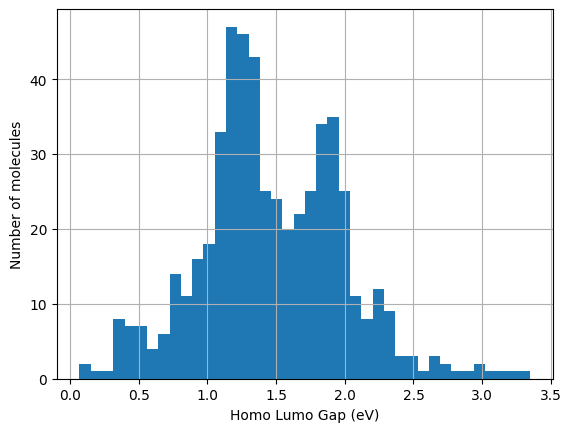

In [17]:
import matplotlib.pyplot as plt

homo_lumo_df["xTB HOMO-LUMO gap / eV"].hist(bins=40)
plt.xlabel ('Homo Lumo Gap (eV)')
plt.ylabel ('Number of molecules')


<Axes: xlabel='Number of Atoms', ylabel='xTB HOMO-LUMO gap / eV'>

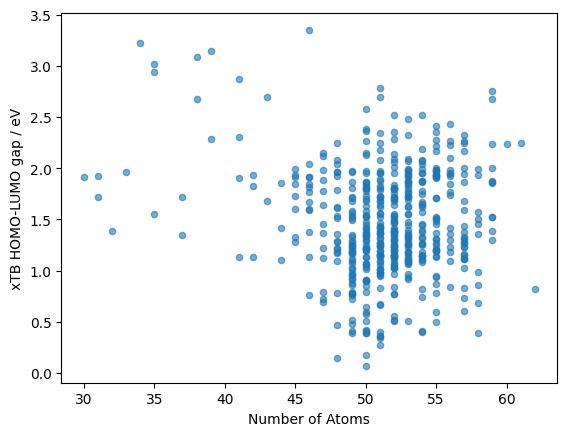

In [18]:
homo_lumo_df.plot.scatter(
    x='Number of Atoms',
    y='xTB HOMO-LUMO gap / eV',
    alpha=0.6
)

<Axes: xlabel='SAscore', ylabel='xTB HOMO-LUMO gap / eV'>

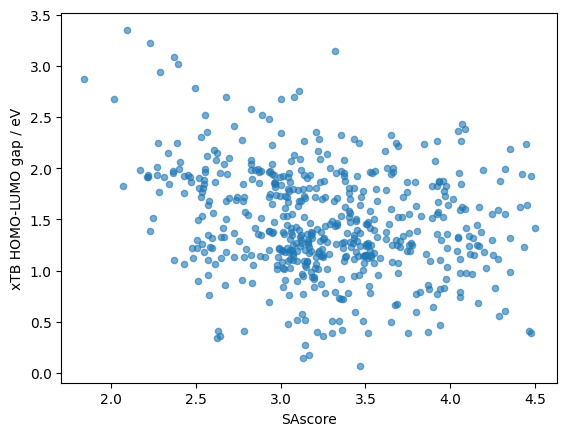

In [19]:
homo_lumo_df.plot.scatter(
    x='SAscore',
    y='xTB HOMO-LUMO gap / eV',
    alpha=0.6
)

In [20]:
cols_to_numeric = [
    "Number of Atoms",
    "SAscore",
    "Tanimoto Similarity",
    "xTB HOMO-LUMO gap / eV"
]

for col in cols_to_numeric:
    homo_lumo_df.loc[:, col] = pd.to_numeric(homo_lumo_df[col], errors="coerce")

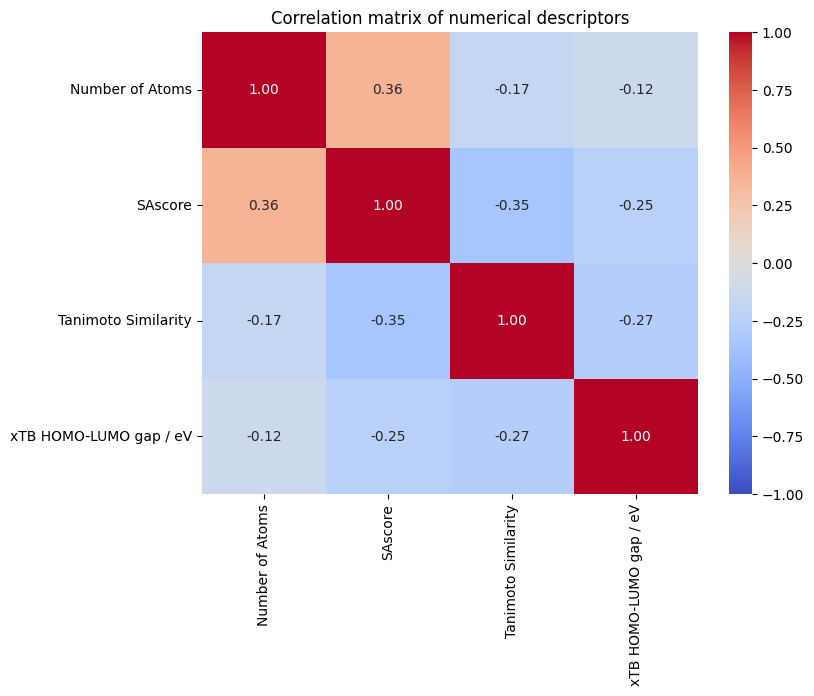

In [21]:
corr = homo_lumo_df[cols_to_numeric].corr()

import seaborn as sns 
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    cmap= "coolwarm",
    annot=True,
    fmt=".2f",
    vmin= -1,
    vmax=1
)
plt.title("Correlation matrix of numerical descriptors")
plt.show()


In [22]:
cols = [
    "xTB HOMO-LUMO gap / eV",
    "HOMO-LUMO Gap / eV"
]

homo_lumo_df = summary_data_df[summary_data_df["xTB HOMO-LUMO gap / eV"].notna()].copy()

for col in cols:
    homo_lumo_df[col] = pd.to_numeric(homo_lumo_df[col], errors="coerce")

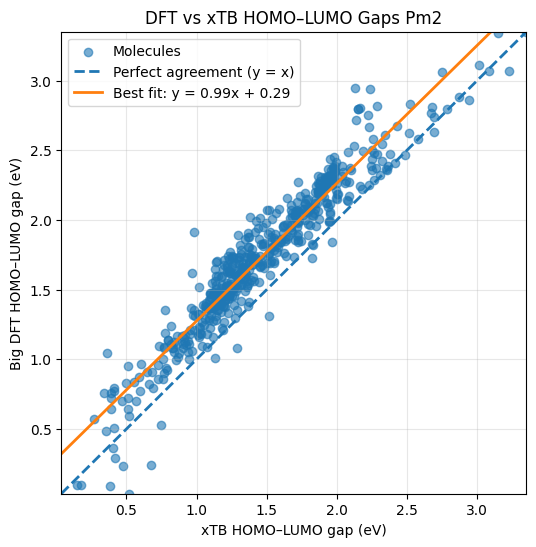

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


tmp = homo_lumo_df[
    ["xTB HOMO-LUMO gap / eV", "HOMO-LUMO Gap / eV"]
].apply(pd.to_numeric, errors="coerce").dropna()

x = tmp["xTB HOMO-LUMO gap / eV"]
y = tmp["HOMO-LUMO Gap / eV"]


plt.figure(figsize=(6, 6))

plt.scatter(x, y, alpha=0.6, label="Molecules")


min_gap = min(x.min(), y.min())
max_gap = max(x.max(), y.max())


plt.plot(
    [min_gap, max_gap],
    [min_gap, max_gap],
    "--",
    linewidth=2,
    label="Perfect agreement (y = x)"
)


m, b = np.polyfit(x, y, 1)

plt.plot(
    [min_gap, max_gap],
    [m * min_gap + b, m * max_gap + b],
    linewidth=2,
    label=f"Best fit: y = {m:.2f}x + {b:.2f}"
)


plt.xlabel("xTB HOMO–LUMO gap (eV)")
plt.ylabel("Big DFT HOMO–LUMO gap (eV)")
plt.title("DFT vs xTB HOMO–LUMO Gaps Pm2")

plt.xlim(min_gap, max_gap)
plt.ylim(min_gap, max_gap)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [17]:
corr = homo_lumo_df["xTB HOMO-LUMO gap / eV"].corr(
    homo_lumo_df["HOMO-LUMO Gap / eV"]
)

print(corr)  

0.9550929965932565


In [18]:
homo_lumo_df["Gap difference / eV"] = (
    homo_lumo_df["HOMO-LUMO Gap / eV"]
    - homo_lumo_df["xTB HOMO-LUMO gap / eV"]
)

homo_lumo_df["Gap difference / eV"].describe()

 

count    532.000000
mean       0.269633
std        0.159583
min       -0.482750
25%        0.186897
50%        0.279296
75%        0.356982
max        0.930845
Name: Gap difference / eV, dtype: float64

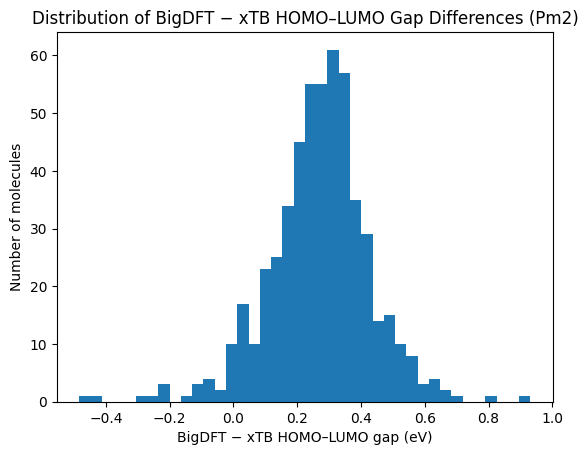

In [19]:
plt.hist(homo_lumo_df["Gap difference / eV"], bins=40)
plt.xlabel("BigDFT − xTB HOMO–LUMO gap (eV)")
plt.ylabel("Number of molecules")
plt.title("Distribution of BigDFT − xTB HOMO–LUMO Gap Differences (Pm2)")
plt.show()


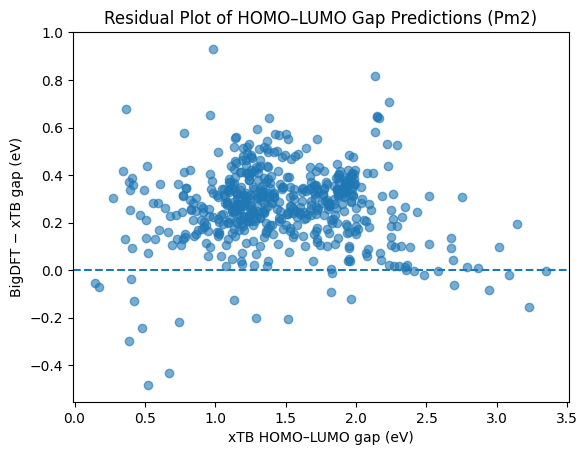

In [20]:
plt.scatter(
    homo_lumo_df["xTB HOMO-LUMO gap / eV"],
    homo_lumo_df["Gap difference / eV"],
    alpha=0.6
)
plt.axhline(0, linestyle="--")
plt.xlabel("xTB HOMO–LUMO gap (eV)")
plt.ylabel("BigDFT − xTB gap (eV)")
plt.title("Residual Plot of HOMO–LUMO Gap Predictions (Pm2)")
plt.show()

In [21]:
outliers = homo_lumo_df.reindex(
    homo_lumo_df["Gap difference / eV"].abs().sort_values(ascending=False).index
)

outliers.head(5)




,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,Connected?,...,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV,Gap difference / eV
1375,Pm2_1375,CC1(C)c2ccccc2N(C2=C=BC(c3cnc(C#N)nc3)C=C2)c2c...,True,False,False,49,0.626168,4.091904,True,True,...,0.9808,True,2.191928,1.911645,0.613356,-5.014945,-3.103299,-8.8729,-7.8921,0.930845
364,Pm2_364,CC1(C)c2ccccc2B(c2ccc(-c3cnc(C#N)nc3)cc2)c2ccc...,True,False,False,50,0.705882,3.076799,True,True,...,2.1332,True,2.268529,2.949386,0.574393,-6.152965,-3.203579,-10.3244,-8.1912,0.816186
1935,Pm2_1935,CCC=C=C1CN(C(C=CCc2cnc(C#N)[nH]2)CC)c2ccccc2C1...,True,False,False,59,0.261194,4.448504,True,True,...,2.2343,True,2.242498,2.942728,0.234448,-4.6826,-1.739872,-9.3534,-7.1191,0.708428
503,Pm2_503,CC1(C)c2ccccc2N(c2ccc(-c3cnc(N=N)nc3)cc2)c2ccc...,False,False,False,51,0.8125,2.645856,True,True,...,0.3641,True,2.561066,1.043024,0.067945,-4.583928,-3.540905,-9.3806,-9.0165,0.678924
1715,Pm2_1715,CC1=C=S2C(=CC1)C(C)(C)c1ccccc1N2c1ccc(-c2cnc(C...,False,False,False,53,0.614679,4.128097,True,True,...,0.9643,True,2.282728,1.617064,0.383064,-4.622549,-3.005485,-9.0774,-8.1131,0.652764


In [22]:
closest = homo_lumo_df.reindex(
    homo_lumo_df["Gap difference / eV"].abs().sort_values(ascending=True).index
)

closest.head(5) 

,Name,SMILES,Eliminated?,Ionic?,Contains Small/Large/No Rings?,Number of Atoms,Tanimoto Similarity,SAscore,FF Converged?,Connected?,...,xTB HOMO-LUMO gap / eV,HOMO-LUMO Converged?,HOMO-LUMO Force / eV/A,HOMO-LUMO Gap / eV,HOMO-LUMO Overlap,HOMO / eV,LUMO / eV,HOMO_xtb_eV,LUMO_xtb_eV,Gap difference / eV
1641,Pm2_1641,CC1(C)c2ccccc2N(c2ccc(C=CN=C(N)N)cc2)c2ccccc21,False,False,False,52,0.560748,2.566755,True,True,...,2.3571,True,0.936792,2.358598,0.144332,-4.272797,-1.914199,-9.0502,-6.6931,0.001498
622,Pm2_622,CNC(C#N)c1ccc(N2c3ccccc3C(C)(C)c3ccccc32)cc1,False,False,False,50,0.623762,2.827872,True,True,...,2.5807,True,2.419335,2.578992,0.194935,-4.557955,-1.978963,-9.3532,-6.7725,-0.001708
1662,Pm2_1662,Cc1ccccc1Nc1ccc(CC(C)c2ccccc2)cc1,True,False,False,46,0.305085,2.092479,True,True,...,3.3508,True,0.551318,3.348086,0.693726,-4.606136,-1.258051,-9.3883,-6.0375,-0.002714
1196,Pm2_1196,CNC(N)=NC=Cc1ccc(N2c3ccccc3C(C)(C)c3ccccc32)cc1,False,False,False,55,0.545455,2.726798,True,True,...,2.4140,True,0.814363,2.410632,0.192505,-4.246709,-1.836077,-9.0263,-6.6123,-0.003368
1082,Pm2_1082,CC1(C)C2=CC=CBC2N(c2ccc(-c3cnc(C#N)nc3)cc2)c2c...,False,False,False,51,0.641509,3.893578,True,True,...,1.8225,True,2.277502,1.828122,0.307914,-5.171182,-3.34306,-9.8063,-7.9838,0.005622


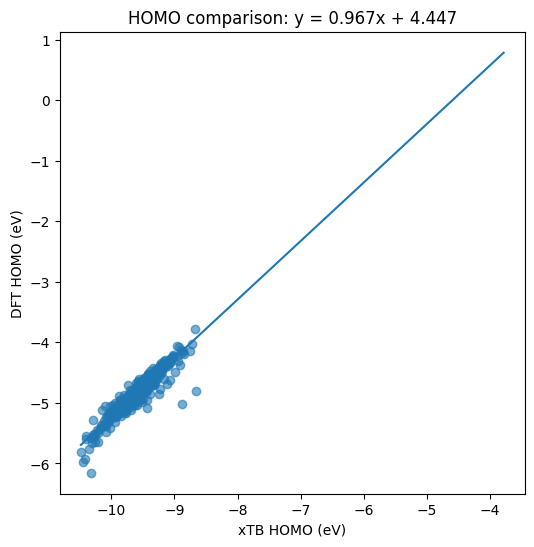

HOMO slope: 0.9674203772788533
HOMO intercept: 4.446952581436794
Points used: 532


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tmp = homo_lumo_df[["HOMO_xtb_eV", "HOMO / eV"]].copy()
tmp["HOMO_xtb_eV"] = pd.to_numeric(tmp["HOMO_xtb_eV"], errors="coerce")
tmp["HOMO / eV"]   = pd.to_numeric(tmp["HOMO / eV"], errors="coerce")
tmp = tmp.dropna()

x = tmp["HOMO_xtb_eV"].to_numpy()
y = tmp["HOMO / eV"].to_numpy()

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())




m, b = np.polyfit(x, y, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b])

plt.xlabel("xTB HOMO (eV)")
plt.ylabel("DFT HOMO (eV)")
plt.title(f"HOMO comparison: y = {m:.3f}x + {b:.3f}")
plt.show()

print("HOMO slope:", m)
print("HOMO intercept:", b)
print("Points used:", len(tmp))

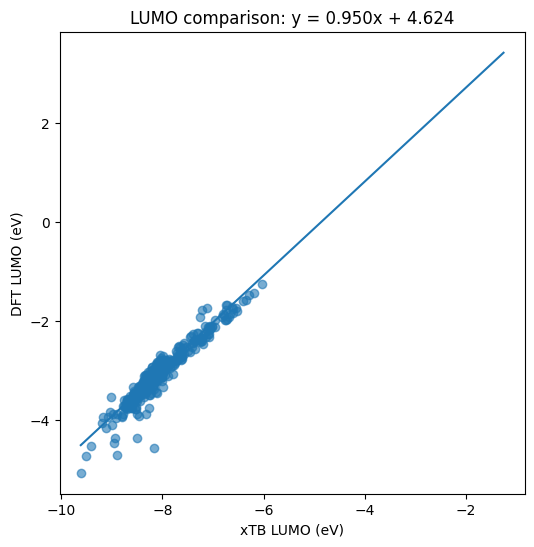

LUMO slope: 0.950115728931807
LUMO intercept: 4.624325173917602
Points used: 532


In [24]:
tmp = homo_lumo_df[["LUMO_xtb_eV", "LUMO / eV"]].copy()
tmp["LUMO_xtb_eV"] = pd.to_numeric(tmp["LUMO_xtb_eV"], errors="coerce")
tmp["LUMO / eV"]   = pd.to_numeric(tmp["LUMO / eV"], errors="coerce")
tmp = tmp.dropna()

x = tmp["LUMO_xtb_eV"].to_numpy()
y = tmp["LUMO / eV"].to_numpy()

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6)

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())


m, b = np.polyfit(x, y, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b])

plt.xlabel("xTB LUMO (eV)")
plt.ylabel("DFT LUMO (eV)")
plt.title(f"LUMO comparison: y = {m:.3f}x + {b:.3f}")
plt.show()

print("LUMO slope:", m)
print("LUMO intercept:", b)
print("Points used:", len(tmp))
